# Outlier case study (XGBoost)

Identifies MOFs consistently mispredicted across the 9 XGBoost conditions (3 feature sets x 3 splits), characterises them structurally (topology, metal node, geometry), classifies them by which descriptor set exposes them, and runs per-structure SHAP case studies. Pipeline step 11.

Inputs:
- models/xgb/optuna/*.joblib
- data/splits/*
- data/merged/hmof_merged.parquet

Output:
- results/prediction-outlier-analysis/outlier_predictions_xgb.parquet
- results/prediction-outlier-analysis/*.png

Environment:
Runs in the core analysis environment (Python 3.11). Key packages: shap, scikit-learn, xgboost, joblib, seaborn, matplotlib, pandas, numpy.

In [38]:
import sys, pathlib, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import shap
warnings.filterwarnings('ignore')

sys.path.insert(0, str(pathlib.Path('..').resolve()))
from src.data_utils import load_experiment

ROOT       = pathlib.Path('..').resolve()
SPLITS_DIR = ROOT / 'data' / 'splits'
MASTER     = ROOT / 'data' / 'merged' / 'hmof_merged.parquet'
MODELS_XG  = ROOT / 'models' / 'xgb' / 'optuna'
SHAP_XG    = ROOT / 'results' / 'xgb' / 'shap'
RESULTS    = ROOT / 'results/prediction-outlier-analysis'

TARGET_IDX  = 2          # co2_mol_kg_0.1bar
FEAT_SETS   = ['geo_all', 'rac_all', 'combined_all']
SPLITS_LIST = ['random', 'topology', 'metal']

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

Generate per-MOF predictions for all 9 XGBoost conditions

In [39]:
records = []

for split in SPLITS_LIST:
    # Names are in the same row-order as the arrays returned by load_experiment()
    names = pd.read_parquet(
        SPLITS_DIR / f'split_{split}_test_merged.parquet', columns=['name']
    )['name'].values

    for fs in FEAT_SETS:
        model_path = MODELS_XG / f'{fs}__{split}.joblib'
        if not model_path.exists():
            print(f'  MISSING: {model_path.name}')
            continue

        _, X_test, _, y_test = load_experiment(split, fs)
        model = joblib.load(model_path)

        y_true    = y_test[:, TARGET_IDX]
        y_pred    = model.predict(X_test)
        residual  = y_pred - y_true
        abs_error = np.abs(residual)

        for i, name in enumerate(names):
            records.append({
                'name': name, 'split': split, 'feature_set': fs,
                'y_true': y_true[i], 'y_pred': y_pred[i],
                'residual': residual[i], 'abs_error': abs_error[i],
            })

        print(f'[done] xgb/{fs}__{split}  '
              f'RMSE={np.sqrt(np.mean(residual**2)):.4f}  '
              f'n={len(names)}')

preds = pd.DataFrame(records)
preds['condition'] = preds['split'] + '__' + preds['feature_set']
preds.to_parquet(RESULTS / 'outlier_predictions_xgb.parquet', index=False)
print(f'\nSaved {len(preds):,} prediction rows covering {preds["name"].nunique():,} unique MOFs')

[done] xgb/geo_all__random  RMSE=0.3736  n=11147
[done] xgb/rac_all__random  RMSE=0.6088  n=11147
[done] xgb/combined_all__random  RMSE=0.3064  n=11147
[done] xgb/geo_all__topology  RMSE=0.3280  n=60
[done] xgb/rac_all__topology  RMSE=0.5749  n=60
[done] xgb/combined_all__topology  RMSE=0.3658  n=60
[done] xgb/geo_all__metal  RMSE=0.3733  n=29234
[done] xgb/rac_all__metal  RMSE=0.6518  n=29234
[done] xgb/combined_all__metal  RMSE=0.3437  n=29234

Saved 121,323 prediction rows covering 37,422 unique MOFs


Flag outliers and compute persistence scores

Outlier threshold per condition: |residual| > 2 * std(abs_error) for that condition

In [40]:
# Per-condition 2σ thresholds
thresholds = (
    preds.groupby('condition')['abs_error']
    .std()
    .mul(2)
    .rename('threshold')
)
preds = preds.join(thresholds, on='condition')
preds['is_outlier'] = preds['abs_error'] > preds['threshold']

print('Outlier rate per condition:')
print(
    preds.groupby('condition')['is_outlier']
    .mean()
    .mul(100)
    .round(1)
    .to_string()
)

Outlier rate per condition:
condition
metal__combined_all        9.7
metal__geo_all            10.6
metal__rac_all             9.1
random__combined_all       9.3
random__geo_all            8.9
random__rac_all            9.0
topology__combined_all    11.7
topology__geo_all         13.3
topology__rac_all          6.7


In [41]:
# Persistence score: fraction of conditions where each MOF is flagged
# (denominator = how many conditions the MOF actually appears in)
n_seen    = preds.groupby('name')['condition'].count()
n_outlier = preds[preds['is_outlier']].groupby('name')['condition'].count()
persistence = (n_outlier / n_seen).fillna(0).sort_values(ascending=False)

print(f'MOFs that are outliers in ALL conditions:    {(persistence == 1.0).sum()}')
print(f'MOFs that are outliers in >50% conditions:  {(persistence > 0.5).sum()}')
print(f'MOFs that are outliers in any condition:    {(persistence > 0).sum()}')
print(f'Total unique MOFs in test sets:             {len(persistence)}')

MOFs that are outliers in ALL conditions:    1112
MOFs that are outliers in >50% conditions:  2920
MOFs that are outliers in any condition:    6840
Total unique MOFs in test sets:             37422


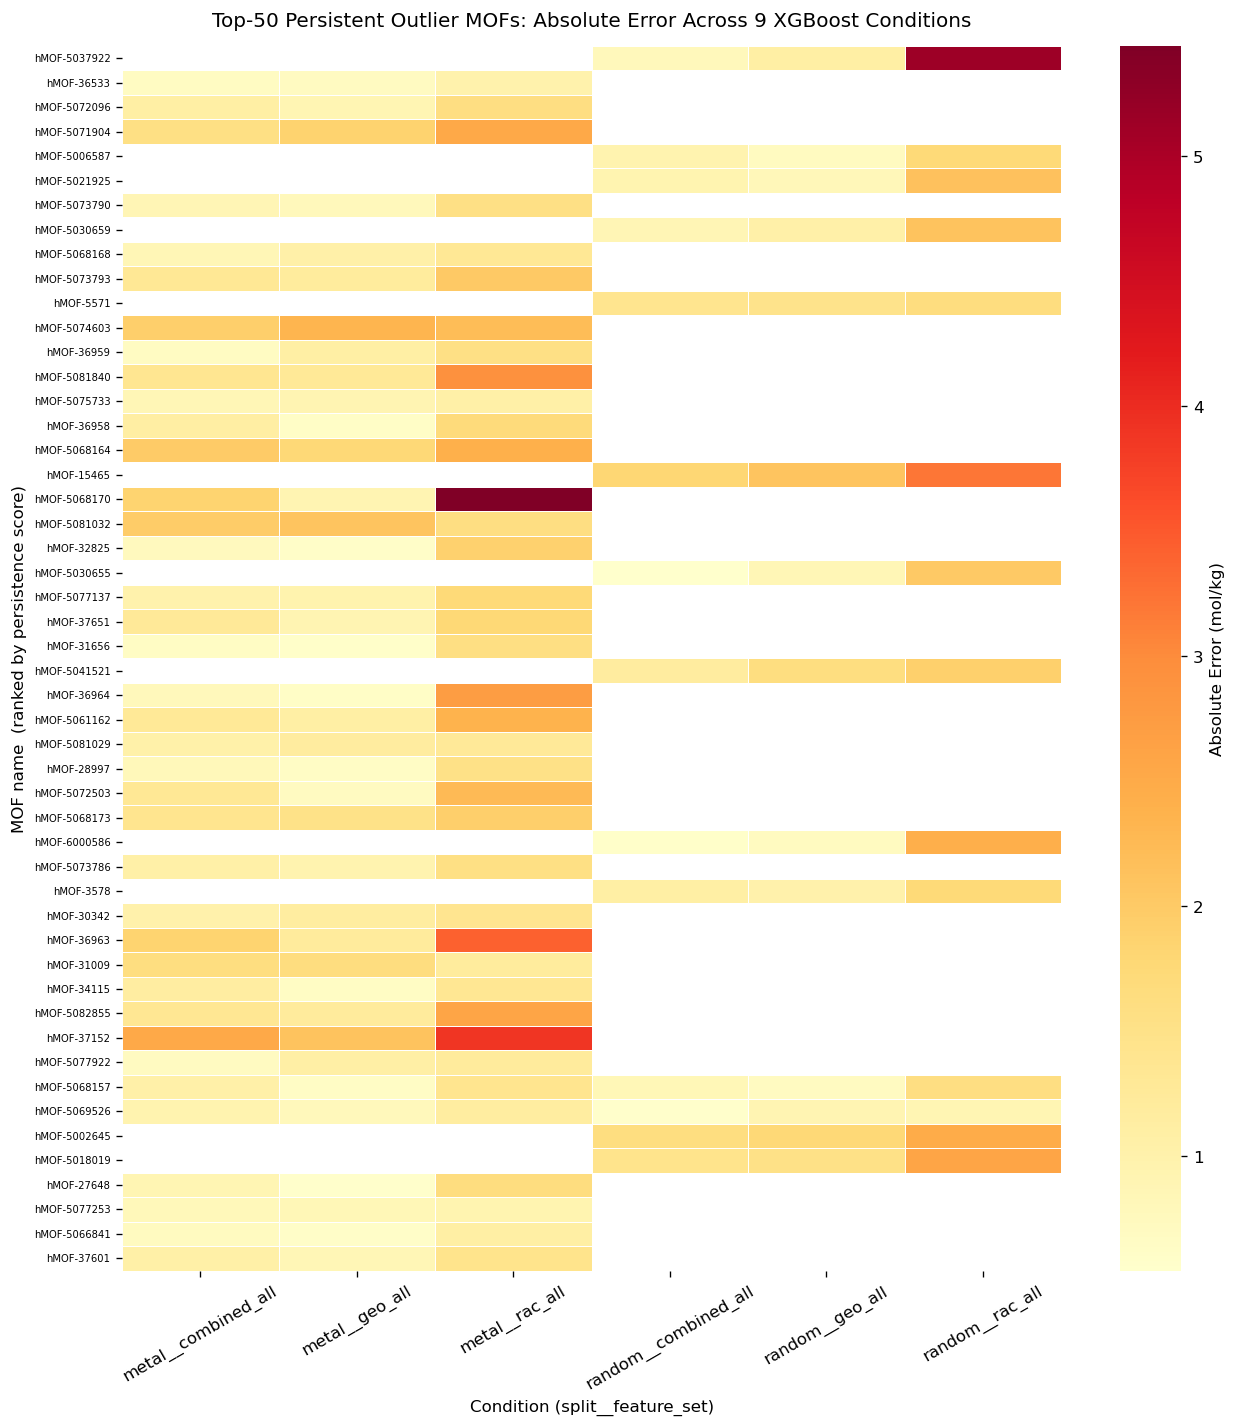

In [42]:
# Heatmap: top-50 persistent MOFs x 9 conditions, colored by abs_error
top50 = persistence.head(50).index

heat_df = (
    preds[preds['name'].isin(top50)]
    .pivot_table(index='name', columns='condition', values='abs_error', aggfunc='mean')
    .loc[top50]   # preserve ranking order
)

fig, ax = plt.subplots(figsize=(11, 12))
sns.heatmap(
    heat_df, ax=ax, cmap='YlOrRd',
    cbar_kws={'label': 'Absolute Error (mol/kg)'},
    linewidths=0.3, linecolor='white'
)
ax.set_title('Top-50 Persistent Outlier MOFs: Absolute Error Across 9 XGBoost Conditions', pad=12)
ax.set_xlabel('Condition (split__feature_set)')
ax.set_ylabel('MOF name  (ranked by persistence score)')
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', labelsize=6)
plt.tight_layout()
plt.savefig(RESULTS / 'outlier_heatmap_xgb.png', bbox_inches='tight')
plt.show()

Structural characterization of persistent outliers

In [43]:
GEO_COLS = ['pld', 'lcd', 'surface_area_m2g', 'void_fraction', 'density_g_cm3']
meta = pd.read_parquet(
    MASTER,
    columns=['name', 'topology', 'metal_node'] + GEO_COLS
).set_index('name')

persistent_threshold = 0.5
top_names  = persistence[persistence >= persistent_threshold].index
meta_out   = meta.loc[meta.index.isin(top_names)]
meta_all   = meta
print(f'Characterizing {len(meta_out)} MOFs with persistence ≥ {persistent_threshold}')

Characterizing 3008 MOFs with persistence ≥ 0.5


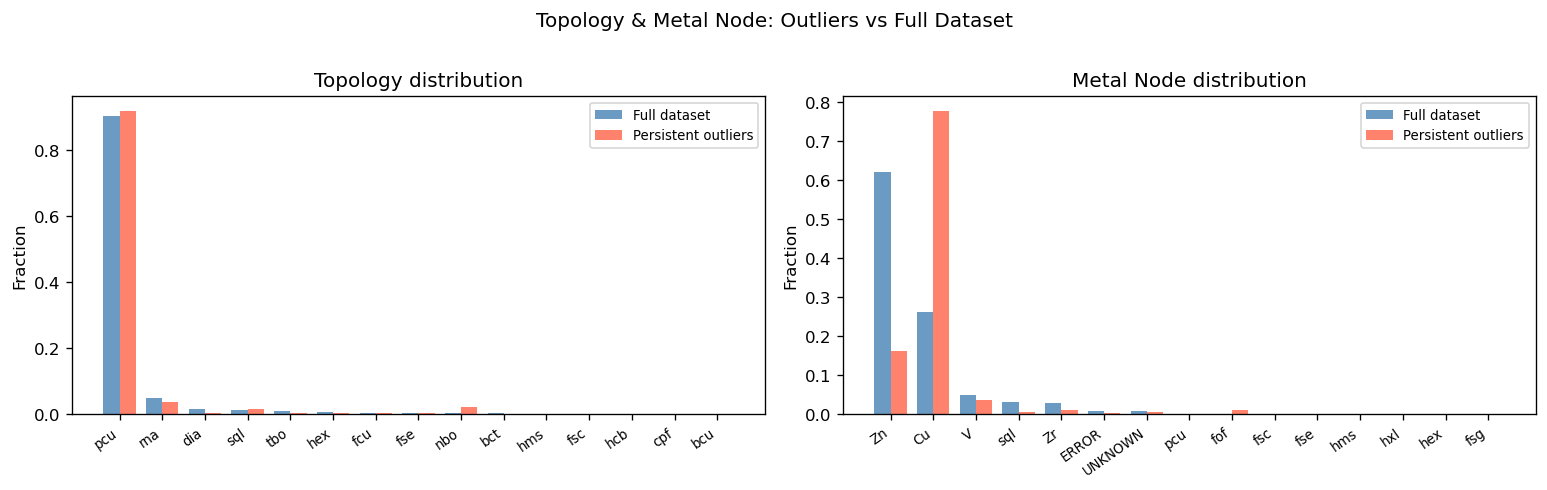

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, title in zip(
    axes,
    ['topology', 'metal_node'],
    ['Topology', 'Metal Node']
):
    frac_all = meta_all[col].value_counts(normalize=True).head(15)
    frac_out = meta_out[col].value_counts(normalize=True).reindex(frac_all.index, fill_value=0)

    x = np.arange(len(frac_all))
    w = 0.38
    ax.bar(x - w/2, frac_all.values, width=w, label='Full dataset', color='steelblue', alpha=0.8)
    ax.bar(x + w/2, frac_out.values, width=w, label=f'Persistent outliers', color='tomato', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(frac_all.index, rotation=35, ha='right', fontsize=8)
    ax.set_ylabel('Fraction')
    ax.set_title(f'{title} distribution')
    ax.legend(fontsize=8)

plt.suptitle('Topology & Metal Node: Outliers vs Full Dataset', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(RESULTS / 'outlier_structure_dist_xgb.png', bbox_inches='tight')
plt.show()

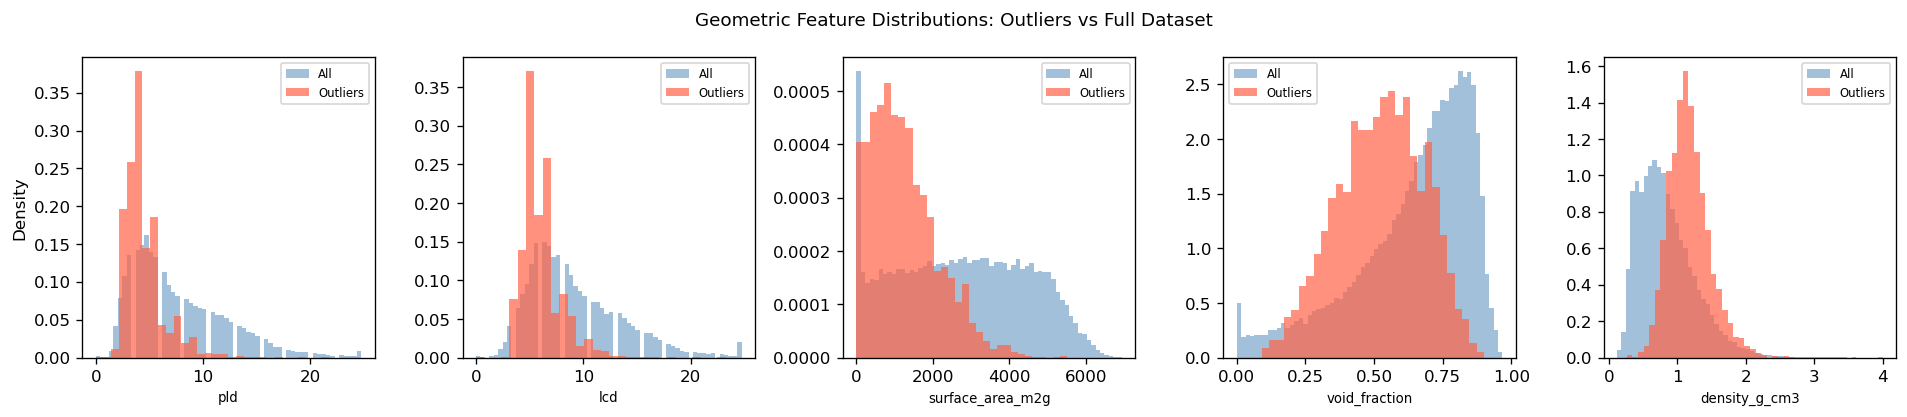

In [45]:
# Geometric feature distributions: outliers vs. full dataset
fig, axes = plt.subplots(1, len(GEO_COLS), figsize=(16, 3.5))

for ax, col in zip(axes, GEO_COLS):
    ax.hist(meta_all[col].dropna(), bins=60, density=True,
            color='steelblue', alpha=0.5, label='All')
    ax.hist(meta_out[col].dropna(), bins=30, density=True,
            color='tomato', alpha=0.7, label='Outliers')
    ax.set_xlabel(col, fontsize=8)
    ax.set_ylabel('Density' if ax == axes[0] else '')
    ax.legend(fontsize=7)

plt.suptitle('Geometric Feature Distributions: Outliers vs Full Dataset', fontsize=11)
plt.tight_layout()
plt.savefig(RESULTS / 'outlier_geo_dist_xgb.png', bbox_inches='tight')
plt.show()

Descriptor-type dissection -> classify each MOF by which feature sets expose it as an outlier

- geo_only: outlier under `geo_all` but NOT `combined_all` → RAC features fix it  
- always: outlier under all three → model-agnostic failure  
- rac_only: outlier under `rac_all` but NOT `combined_all`

In [46]:
# For each (MOF, feature_set): is it an outlier in ANY split under that feature set?
outlier_any_split = (
    preds[preds['is_outlier']]
    .groupby(['name', 'feature_set'])
    .size()
    .gt(0)
    .unstack(fill_value=False)
)
# Ensure all three columns present
for fs in FEAT_SETS:
    if fs not in outlier_any_split.columns:
        outlier_any_split[fs] = False

geo = outlier_any_split['geo_all']
rac = outlier_any_split['rac_all']
comb = outlier_any_split['combined_all']

categories = {
    'Geo only\n(RAC fixes it)':    (geo & ~comb).sum(),
    'RAC only\n(geo fixes it)':    (rac & ~comb).sum(),
    'Always outlier\n(all 3)':     (geo & rac & comb).sum(),
    'Combined only':               (~geo & ~rac & comb).sum(),
    'Never outlier':               (~geo & ~rac & ~comb).sum(),
}

print('MOF counts by outlier category:')
for k, v in categories.items():
    print(f'  {k.replace(chr(10), " "):35s}: {v}')

MOF counts by outlier category:
  Geo only (RAC fixes it)            : 1508
  RAC only (geo fixes it)            : 1809
  Always outlier (all 3)             : 1166
  Combined only                      : 882
  Never outlier                      : 0


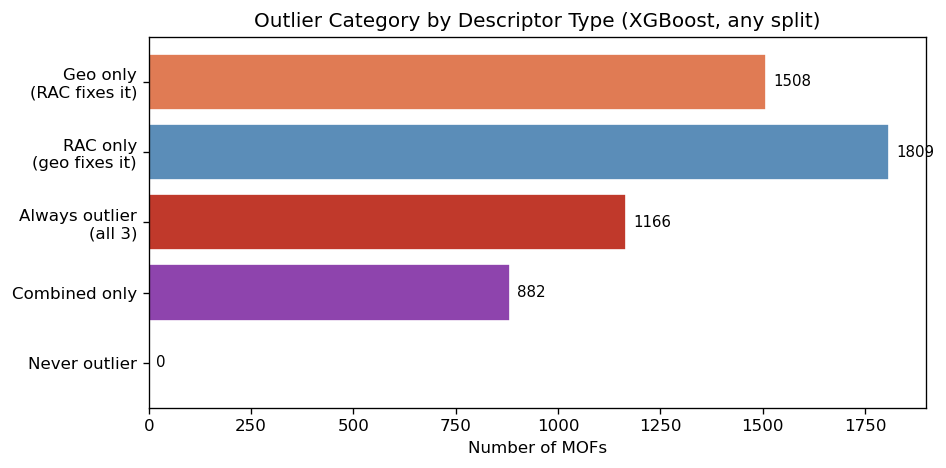

In [47]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#e07b54', '#5b8db8', '#c0392b', '#8e44ad', '#95a5a6']
labels = list(categories.keys())
values = list(categories.values())

bars = ax.barh(labels, values, color=colors, edgecolor='white')
for bar, val in zip(bars, values):
    ax.text(bar.get_width() + max(values)*0.01, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)

ax.set_xlabel('Number of MOFs')
ax.set_title('Outlier Category by Descriptor Type (XGBoost, any split)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(RESULTS / 'outlier_descriptor_categories_xgb.png', bbox_inches='tight')
plt.show()

In [48]:
# Identify the 'geo only' MOFs
geo_only_mask = geo & ~comb
geo_only_mofs = outlier_any_split[geo_only_mask].index.tolist()
print(f'"Geo only" outliers (RAC/combined fixes them): {len(geo_only_mofs)}')

# Show their error improvement: geo_all vs combined_all
geo_only_preds = preds[preds['name'].isin(geo_only_mofs)].copy()
error_by_fs = (
    geo_only_preds
    .groupby(['name', 'feature_set'])['abs_error']
    .mean()
    .unstack()
    [FEAT_SETS]
)
error_by_fs['improvement'] = error_by_fs['geo_all'] - error_by_fs['combined_all']
print('\nTop 10 geo-only outliers by error improvement (geo_all → combined_all):')
print(error_by_fs.sort_values('improvement', ascending=False).head(10).round(4).to_string())

"Geo only" outliers (RAC/combined fixes them): 1508

Top 10 geo-only outliers by error improvement (geo_all → combined_all):
feature_set   geo_all  rac_all  combined_all  improvement
name                                                     
hMOF-5011043   2.8996   2.3284        0.3215       2.5781
hMOF-5015978   2.8051   2.4933        0.3277       2.4774
hMOF-5011051   2.2537   2.0661        0.2214       2.0323
hMOF-5080034   2.4693   0.6699        0.4493       2.0201
hMOF-5082321   2.1655   1.6757        0.2966       1.8690
hMOF-5082333   2.2385   1.2703        0.4958       1.7427
hMOF-5082323   1.8738   1.8558        0.2172       1.6566
hMOF-6000600   1.5530   2.0242        0.0078       1.5451
hMOF-6001327   1.8520   2.8528        0.3795       1.4725
hMOF-6005111   1.4630   1.2840        0.0413       1.4217


SHAP case study for selected outliers

Pick the top 3 "geo only" outliers (biggest error improvement when adding RAC features) and show what SHAP says about each.

In [49]:
# Select case-study MOFs: top 3 by error improvement under random split
# (random split is cleanest for interpretation — no topology/metal confounding)
case_mofs = (
    error_by_fs
    .sort_values('improvement', ascending=False)
    .head(3)
    .index
    .tolist()
)
print('Case-study MOFs:', case_mofs)

Case-study MOFs: ['hMOF-5011043', 'hMOF-5015978', 'hMOF-5011051']


In [50]:
def get_shap_for_mof(mof_name, split, feature_set, n_bg=300):
    """Compute SHAP waterfall data for one MOF.
    
    First tries to reuse the cached .npz SHAP file (500 samples).
    Falls back to computing fresh via PermutationExplainer.
    Returns (shap_values_1d, feature_values_1d, feature_names, expected_value).
    """
    model_path = MODELS_XG / f'{feature_set}__{split}.joblib'
    model = joblib.load(model_path)

    X_train, X_test, y_train, y_test = load_experiment(split, feature_set)
    names_test = pd.read_parquet(
        SPLITS_DIR / f'split_{split}_test_merged.parquet', columns=['name']
    )['name'].values

    feat_cfg = json.loads((ROOT / 'data' / 'merged' / 'feature_selection.json').read_text())
    feature_names = feat_cfg['feature_sets'][feature_set]

    mof_idx = np.where(names_test == mof_name)[0]
    if len(mof_idx) == 0:
        return None   # MOF not in this split's test set
    mof_idx = mof_idx[0]

    # Try cached .npz
    npz_path = SHAP_XG / f'{feature_set}__{split}.npz'
    shap_row = None
    if npz_path.exists():
        cached = np.load(npz_path, allow_pickle=True)
        X_explain = cached['X_explain']        # (n_explain, n_features)
        shap_vals  = cached['shap_values']     # (n_explain, n_features)
        exp_val    = float(cached['expected_value'])
        # Match by feature vector (exact float match)
        mof_row = X_test[mof_idx]
        diffs = np.abs(X_explain - mof_row).sum(axis=1)
        best  = diffs.argmin()
        if diffs[best] < 1e-8:
            shap_row = shap_vals[best]
            x_row    = X_explain[best]

    if shap_row is None:
        # Compute fresh — base_values lives on the Explanation object, not the explainer
        bg = shap.sample(X_train, n_bg, random_state=42)
        explainer = shap.PermutationExplainer(model.predict, bg)
        explanation = explainer(X_test[[mof_idx]])
        shap_row = explanation.values[0]
        x_row    = X_test[mof_idx]
        exp_val  = float(explanation.base_values[0])

    return shap_row, x_row, feature_names, exp_val

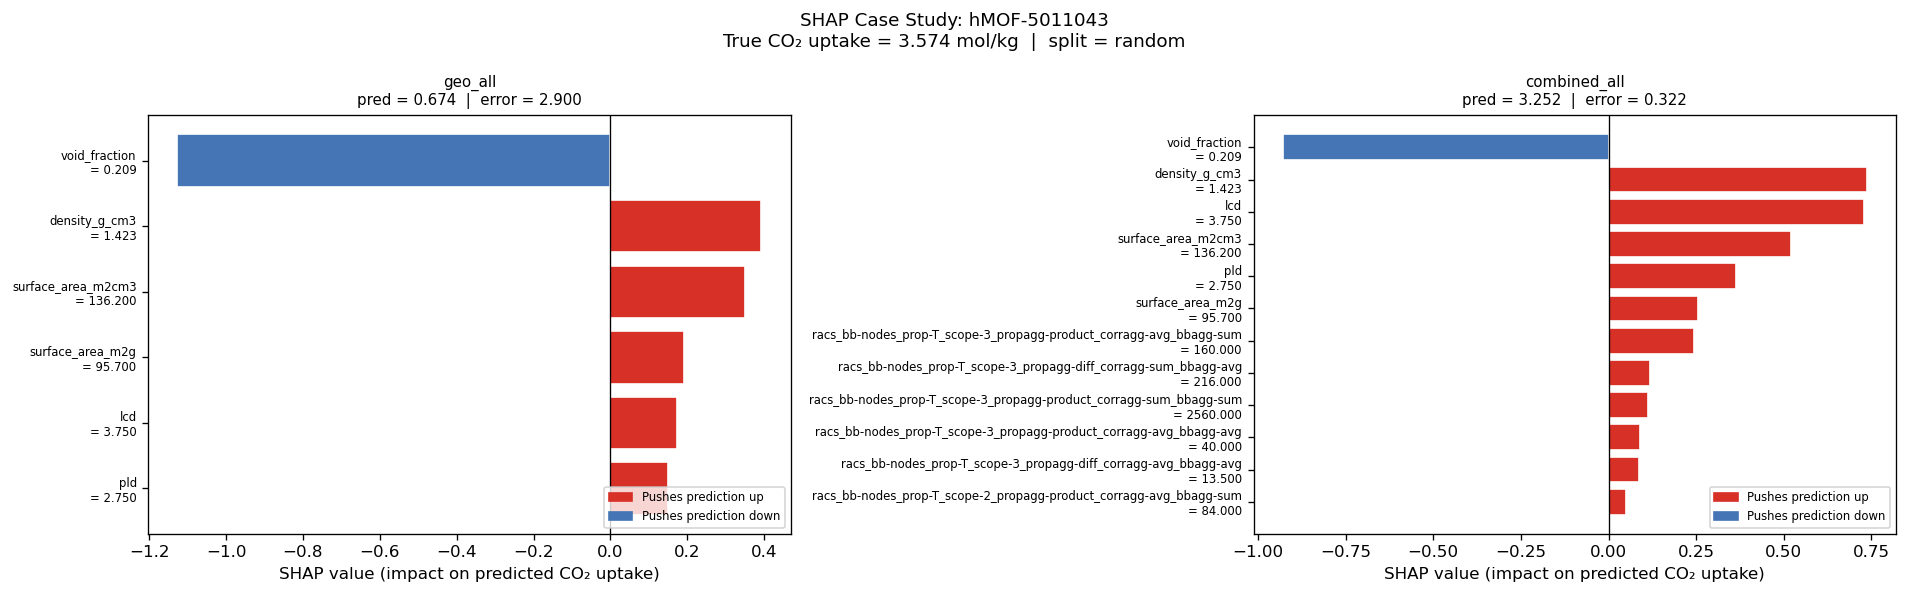

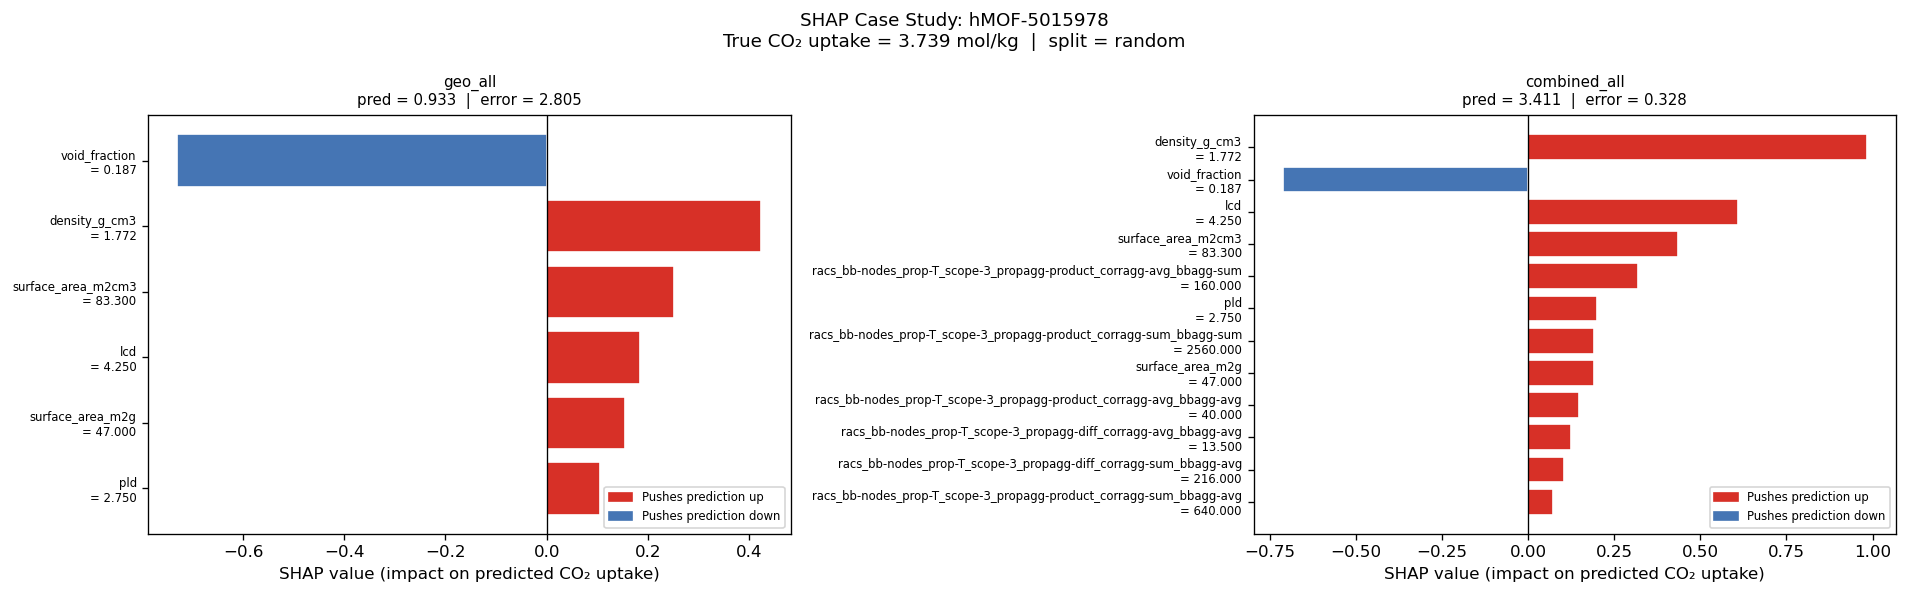

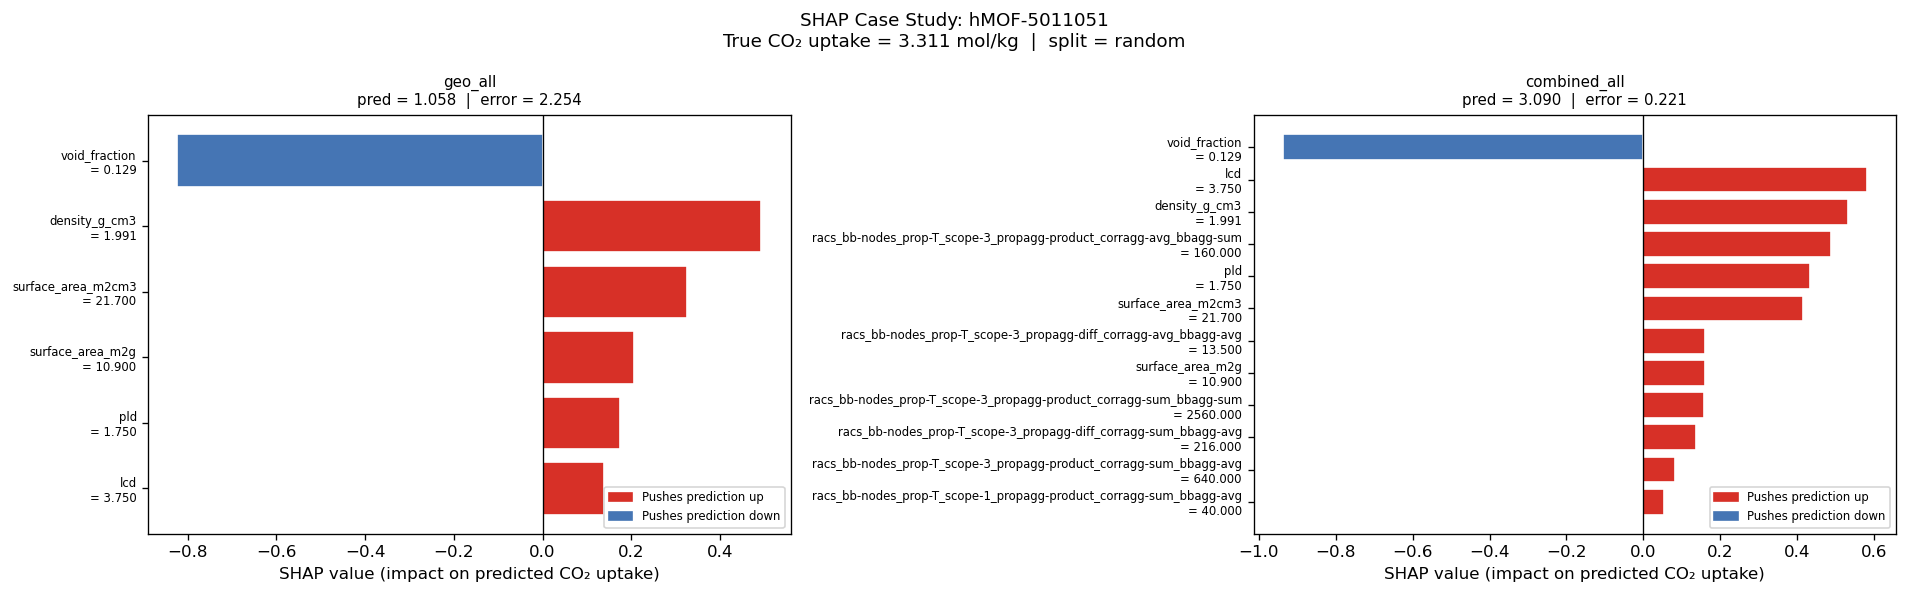

In [51]:
# For each case-study MOF: side-by-side waterfall geo_all vs combined_all (random split)
SPLIT_CS = 'random'

for mof in case_mofs:
    row = preds[(preds['name'] == mof) & (preds['split'] == SPLIT_CS)]
    y_true_val = row['y_true'].iloc[0] if len(row) else float('nan')

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(
        f'SHAP Case Study: {mof}\n'
        f'True CO₂ uptake = {y_true_val:.3f} mol/kg  |  split = {SPLIT_CS}',
        fontsize=11
    )

    for ax, fs in zip(axes, ['geo_all', 'combined_all']):
        result = get_shap_for_mof(mof, SPLIT_CS, fs)
        if result is None:
            ax.text(0.5, 0.5, f'MOF not in {SPLIT_CS} test set', transform=ax.transAxes, ha='center')
            ax.set_title(fs)
            continue

        sv, xv, fn, ev = result
        pred_val = ev + sv.sum()

        mof_row_pred = preds[(preds['name'] == mof) &
                             (preds['split'] == SPLIT_CS) &
                             (preds['feature_set'] == fs)]
        pred_display = mof_row_pred['y_pred'].iloc[0] if len(mof_row_pred) else pred_val
        err_display  = mof_row_pred['abs_error'].iloc[0] if len(mof_row_pred) else abs(pred_val - y_true_val)

        # Top-N features by |SHAP|
        N = min(12, len(sv))
        order = np.argsort(np.abs(sv))[::-1][:N]
        sv_top = sv[order]
        fn_top = [fn[i] for i in order]
        xv_top = xv[order]

        colors = ['#d73027' if v > 0 else '#4575b4' for v in sv_top]
        y_pos  = np.arange(N)
        ax.barh(y_pos, sv_top, color=colors, edgecolor='white')
        ax.set_yticks(y_pos)
        ax.set_yticklabels(
            [f'{n}\n= {v:.3f}' for n, v in zip(fn_top, xv_top)],
            fontsize=7
        )
        ax.invert_yaxis()
        ax.axvline(0, color='black', lw=0.8)
        ax.set_xlabel('SHAP value (impact on predicted CO₂ uptake)')
        ax.set_title(
            f'{fs}\npred = {pred_display:.3f}  |  error = {err_display:.3f}',
            fontsize=9
        )
        red_patch   = mpatches.Patch(color='#d73027', label='Pushes prediction up')
        blue_patch  = mpatches.Patch(color='#4575b4', label='Pushes prediction down')
        ax.legend(handles=[red_patch, blue_patch], fontsize=7, loc='lower right')

    plt.tight_layout()
    safe_name = mof.replace('/', '_').replace(' ', '_')
    plt.savefig(RESULTS / f'outlier_shap_{safe_name}_xgb.png', bbox_inches='tight')
    plt.show()